In [1]:
# Library utama untuk pengolahan dan analisis data
import pandas as pd
import numpy as np

# Library untuk visualisasi data
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Library untuk mengelola pesan warning
import warnings

# Metrik evaluasi yang akan digunakan untuk mengukur performa model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Menyembunyikan warning agar output notebook lebih rapi
warnings.filterwarnings('ignore')

# Memuat dataset hasil preprocessing dari file parquet
# (sudah berisi Kota_encoded, Angkatan_Kerja, dan Jumlah_Penduduk)
data = pd.read_parquet("data_clean.parquet")

# Menampilkan informasi dasar dataset yang berhasil dimuat
print("Data berhasil dimuat dari data_clean.parquet")
print(f"Shape  : {data.shape}")
print(f"Kolom  : {list(data.columns)}")

# Menampilkan 5 baris pertama dataset untuk pengecekan awal
data.head()

Data berhasil dimuat dari data_clean.parquet
Shape  : (210, 14)
Kolom  : ['Kabupaten/Kota', 'Tahun', 'TPT', 'PDRB_ADHK', 'IPM', 'TPAK', 'Jumlah_Industri', 'Jumlah_Tenaga_Kerja', 'Distribusi_Penduduk', 'Pertumbuhan_Penduduk', 'Kepadatan_Penduduk', 'Jumlah_Penduduk', 'Angkatan_Kerja', 'Kota_encoded']


,Kabupaten/Kota,Tahun,TPT,PDRB_ADHK,IPM,TPAK,Jumlah_Industri,Jumlah_Tenaga_Kerja,Distribusi_Penduduk,Pertumbuhan_Penduduk,Kepadatan_Penduduk,Jumlah_Penduduk,Angkatan_Kerja,Kota_encoded
0,Cilacap,2018,7.49,98100.57,68.90,62.62,5637,44644,4.99,0.46,804,1719.504,799403.0,6
1,Cilacap,2019,7.24,100327.30,69.98,65.34,3249,5952,4.97,0.54,813,1727.100,841689.0,6
2,Cilacap,2020,9.10,90011.58,65.72,67.79,3207,5952,5.33,1.65,915,1944.857,888218.0,6
3,Cilacap,2021,9.97,91944.59,70.66,62.91,5567,14803,5.34,1.30,924,1963.824,830043.0,6
4,Cilacap,2022,9.62,96677.84,71.22,65.65,5819,16626,5.37,1.28,930,1988.600,872454.0,6


In [2]:
# Fungsi untuk membagi data menjadi data latih dan data uji
from sklearn.model_selection import train_test_split

# Menentukan nama variabel target
TARGET = 'TPT'

# [REVISI] Fitur sekarang menyertakan Kota_encoded dan Tahun
# Kolom non-fitur yang dibuang hanya Kabupaten/Kota (string) dan TARGET
FITUR = [
    'PDRB_ADHK', 'IPM', 'TPAK',
    'Jumlah_Industri', 'Jumlah_Tenaga_Kerja',
    'Distribusi_Penduduk', 'Pertumbuhan_Penduduk', 'Kepadatan_Penduduk',
    'Kota_encoded', 'Tahun'
]

# Membentuk data fitur (X) dan target (y)
X = data[FITUR]
y = data[TARGET]

# Membagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Menampilkan ukuran data setelah proses pembagian
print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test : {X_test.shape}")
print(f"Fitur digunakan: {FITUR}")

Shape X_train: (168, 10)
Shape X_test : (42, 10)
Fitur digunakan: ['PDRB_ADHK', 'IPM', 'TPAK', 'Jumlah_Industri', 'Jumlah_Tenaga_Kerja', 'Distribusi_Penduduk', 'Pertumbuhan_Penduduk', 'Kepadatan_Penduduk', 'Kota_encoded', 'Tahun']


In [3]:
# Model Regresi Linear untuk memprediksi nilai TPT
from sklearn.linear_model import LinearRegression

# Metrik evaluasi yang digunakan untuk mengukur performa model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Membuat objek model Regresi Linear
lr_model = LinearRegression()

# Melatih model menggunakan data training
lr_model.fit(X_train, y_train)

# Melakukan prediksi pada data testing
y_pred_lr = lr_model.predict(X_test)

# Menampilkan parameter utama hasil pelatihan model
print("=" * 55)
print("       PARAMETER MODEL REGRESI LINEAR")
print("=" * 55)

# Menampilkan nilai intercept (konstanta) model
print(f"  Intercept : {lr_model.intercept_:.4f}")

# Menggabungkan nama variabel dan nilai koefisien ke dalam DataFrame
coef_df = pd.DataFrame({
    'Variabel': X_train.columns,
    'Koefisien': lr_model.coef_
})

# Mengurutkan koefisien berdasarkan nilai absolut terbesar
coef_df = coef_df.sort_values('Koefisien', key=abs, ascending=False)

print("\n  Koefisien Variabel:")

# Menampilkan tabel koefisien setiap variabel
display(coef_df)

print("=" * 55)

       PARAMETER MODEL REGRESI LINEAR
  Intercept : -573.2128

  Koefisien Variabel:


,Variabel,Koefisien
6,Pertumbuhan_Penduduk,0.851223
9,Tahun,0.295853
2,TPAK,-0.157683
1,IPM,-0.127525
5,Distribusi_Penduduk,-0.092001
8,Kota_encoded,-0.025111
7,Kepadatan_Penduduk,0.000317
3,Jumlah_Industri,-0.000029
0,PDRB_ADHK,0.000028
4,Jumlah_Tenaga_Kerja,-0.000008


In [4]:
# Model Random Forest dan tools untuk hyperparameter tuning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold

# Menentukan kombinasi hyperparameter yang akan diuji
rf_param_grid = {
    'n_estimators'     : [100, 200, 300, 400, 500],
    'max_depth'        : [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5]
}

# Membuat skema 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Melakukan pencarian kombinasi hyperparameter terbaik secara acak
rf_random = RandomizedSearchCV(
    estimator     = RandomForestRegressor(random_state=42),
    param_distributions = rf_param_grid,
    n_iter        = 50,
    cv            = kf,
    scoring       = 'neg_mean_squared_error',
    random_state  = 42,
    n_jobs        = -1,
    verbose       = 1
)

# Memulai proses tuning untuk mencari parameter terbaik
print("Memulai Hyperparameter Tuning — Random Forest ...")
rf_random.fit(X_train, y_train)

# Menampilkan hasil tuning
print("\nTuning selesai!")
print(f"Best Params : {rf_random.best_params_}")
print(f"Best CV MSE : {-rf_random.best_score_:.4f}")

Memulai Hyperparameter Tuning — Random Forest ...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Tuning selesai!
Best Params : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}
Best CV MSE : 1.5100


In [5]:
# Model XGBoost untuk tugas regresi
from xgboost import XGBRegressor

# Menentukan kombinasi hyperparameter yang akan diuji
xgb_param_grid = {
    'n_estimators'     : [100, 200, 300, 400, 500],
    'max_depth'        : [3, 5, 7, 9],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.6, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.8, 1.0],
    'min_child_weight' : [1, 3, 5],
    'gamma'            : [0, 0.1, 0.3]
}

# Melakukan pencarian hyperparameter terbaik menggunakan Randomized Search
xgb_random = RandomizedSearchCV(
    estimator     = XGBRegressor(random_state=42, verbosity=0),
    param_distributions = xgb_param_grid,
    n_iter        = 50,
    cv            = kf,
    scoring       = 'neg_mean_squared_error',
    random_state  = 42,
    n_jobs        = -1,
    verbose       = 1
)

# Memulai proses tuning untuk mendapatkan konfigurasi model terbaik
print("Memulai Hyperparameter Tuning — XGBoost ...")
xgb_random.fit(X_train, y_train)

# Menampilkan hasil tuning yang diperoleh
print("\nTuning selesai!")
print(f"Best Params : {xgb_random.best_params_}")
print(f"Best CV MSE : {-xgb_random.best_score_:.4f}")

Memulai Hyperparameter Tuning — XGBoost ...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Tuning selesai!
Best Params : {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV MSE : 1.3222


In [6]:
# ── Ambil best estimator dari hasil tuning ──
rf_best  = rf_random.best_estimator_
xgb_best = xgb_random.best_estimator_

# ── Prediksi ketiga model ──
y_pred_lr  = lr_model.predict(X_test)
y_pred_rf  = rf_best.predict(X_test)
y_pred_xgb = xgb_best.predict(X_test)

print("Prediksi ketiga model selesai")
print(f"y_pred_lr  : {len(y_pred_lr)} nilai")
print(f"y_pred_rf  : {len(y_pred_rf)} nilai")
print(f"y_pred_xgb : {len(y_pred_xgb)} nilai")

Prediksi ketiga model selesai
y_pred_lr  : 42 nilai
y_pred_rf  : 42 nilai
y_pred_xgb : 42 nilai


In [7]:
# Fungsi untuk menghitung Mean Absolute Percentage Error (MAPE)
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Fungsi untuk menghitung berbagai metrik evaluasi model
def evaluate_model(name, y_true, y_pred):
    r2       = r2_score(y_true, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    mae      = mean_absolute_error(y_true, y_pred)
    mape_val = mape(y_true, y_pred)
    return {
        'Model'   : name,
        'R²'      : round(r2, 4),
        'RMSE'    : round(rmse, 4),
        'MAE'     : round(mae, 4),
        'MAPE (%)': round(mape_val, 4)
    }

# Menghitung performa masing-masing model
results = [
    evaluate_model('Regresi Linear (Baseline)', y_test, y_pred_lr),
    evaluate_model('Random Forest (Tuned)',     y_test, y_pred_rf),
    evaluate_model('XGBoost (Tuned)',           y_test, y_pred_xgb),
]

results_df = pd.DataFrame(results)

print("=" * 65)
print("           PERBANDINGAN PERFORMA MODEL")
print("=" * 65)
display(results_df)
print("=" * 65)

best_model_row = results_df.loc[results_df['MAPE (%)'].idxmin()]
print(f"\nModel Terbaik (MAPE terendah): {best_model_row['Model']}")
print(f"MAPE = {best_model_row['MAPE (%)']}%  |  R² = {best_model_row['R²']}")

           PERBANDINGAN PERFORMA MODEL


,Model,R²,RMSE,MAE,MAPE (%)
0,Regresi Linear (Baseline),0.3977,1.6321,1.3550,31.6304
1,Random Forest (Tuned),0.7196,1.1136,0.9161,21.6018
2,XGBoost (Tuned),0.8515,0.8105,0.6566,15.7116



Model Terbaik (MAPE terendah): XGBoost (Tuned)
MAPE = 15.7116%  |  R² = 0.8515


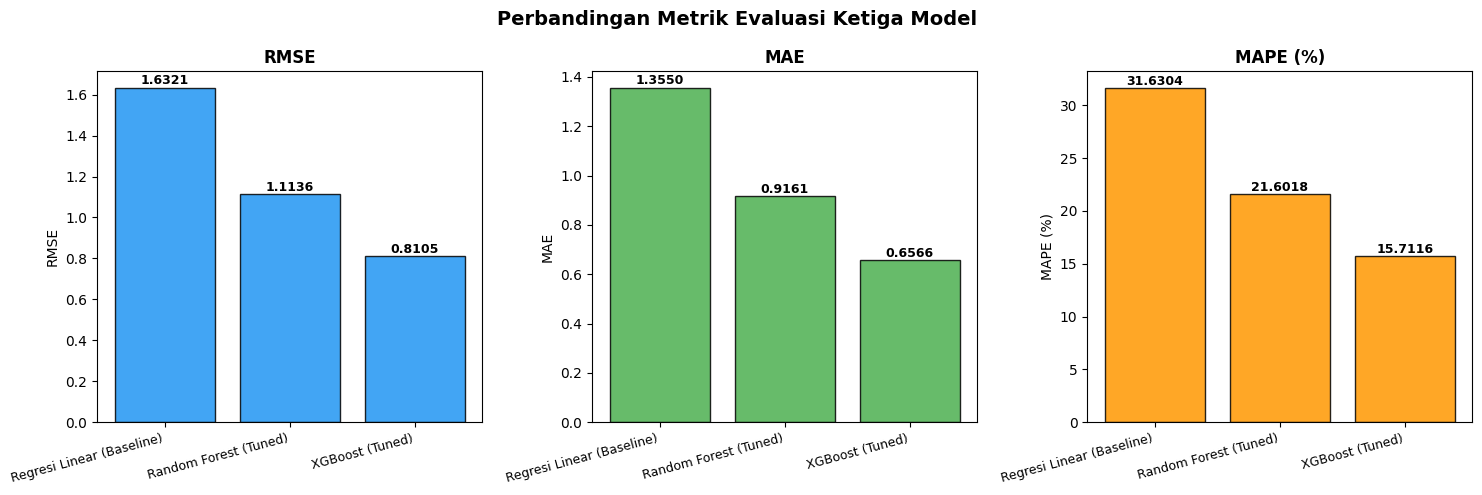

Grafik disimpan: evaluasi_model_comparison.png


In [8]:
# Membuat visualisasi perbandingan metrik evaluasi antar model
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Perbandingan Metrik Evaluasi Ketiga Model', fontsize=14, fontweight='bold')

metrics = ['RMSE', 'MAE', 'MAPE (%)']
colors  = ['#2196F3', '#4CAF50', '#FF9800']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results_df['Model'], results_df[metric],
                  color=color, alpha=0.85, edgecolor='black')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('evaluasi_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: evaluasi_model_comparison.png")

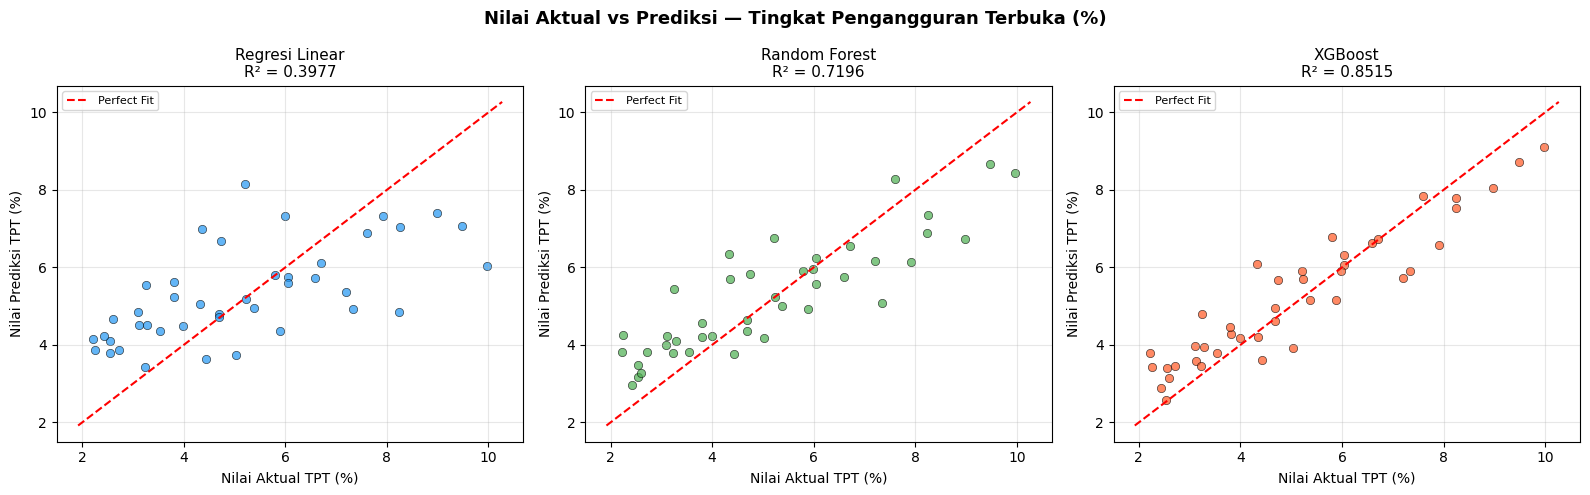

Grafik disimpan: aktual_vs_prediksi.png


In [9]:
# Membuat visualisasi perbandingan antara nilai aktual dan hasil prediksi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Nilai Aktual vs Prediksi — Tingkat Pengangguran Terbuka (%)',
             fontsize=13, fontweight='bold')

model_preds = [
    ('Regresi Linear', y_pred_lr,  '#2196F3'),
    ('Random Forest',  y_pred_rf,  '#4CAF50'),
    ('XGBoost',        y_pred_xgb, '#FF5722'),
]

for ax, (name, y_pred, color) in zip(axes, model_preds):
    ax.scatter(y_test, y_pred, alpha=0.7, color=color, edgecolors='black', linewidth=0.5)
    lim_min = min(y_test.min(), y_pred.min()) - 0.3
    lim_max = max(y_test.max(), y_pred.max()) + 0.3
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5, label='Perfect Fit')
    r2_val = r2_score(y_test, y_pred)
    ax.set_title(f'{name}\nR² = {r2_val:.4f}', fontsize=11)
    ax.set_xlabel('Nilai Aktual TPT (%)')
    ax.set_ylabel('Nilai Prediksi TPT (%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('aktual_vs_prediksi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: aktual_vs_prediksi.png")

   FEATURE IMPORTANCE — Random Forest (Semua Kota)


,Variabel,Importance
0,Distribusi_Penduduk,0.262362
1,TPAK,0.164548
2,Kepadatan_Penduduk,0.129507
3,Pertumbuhan_Penduduk,0.122697
4,PDRB_ADHK,0.102963
5,IPM,0.074315
6,Jumlah_Tenaga_Kerja,0.072320
7,Jumlah_Industri,0.071288


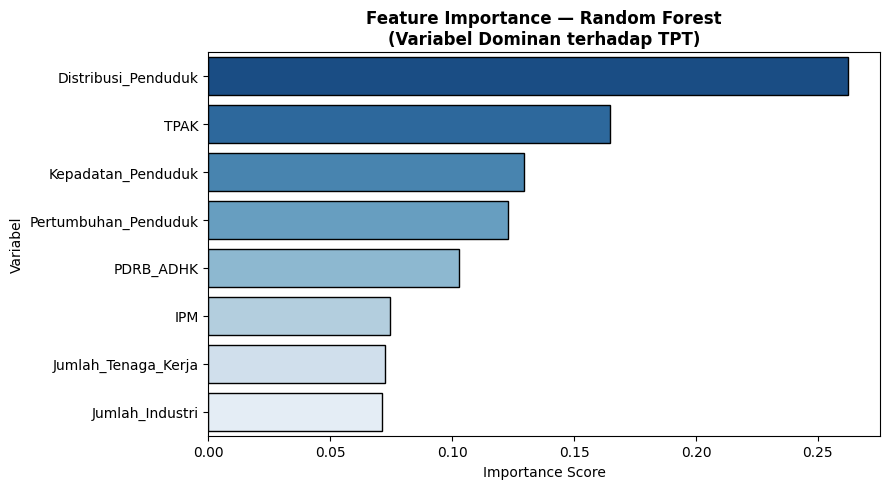

Grafik disimpan: feature_importance_rf.png


In [10]:
# Variabel sosial ekonomi yang ingin divisualisasikan (tanpa Kota_encoded & Tahun)
FITUR_SOSEK = [
    'PDRB_ADHK', 'IPM', 'TPAK',
    'Jumlah_Industri', 'Jumlah_Tenaga_Kerja',
    'Distribusi_Penduduk', 'Pertumbuhan_Penduduk', 'Kepadatan_Penduduk'
]

# Hitung feature importance dari semua fitur (termasuk Kota_encoded & Tahun)
fi_rf = pd.DataFrame({
    'Variabel'   : X_train.columns,
    'Importance' : rf_best.feature_importances_
})
fi_rf = fi_rf.sort_values('Importance', ascending=False)

# Filter hanya 8 variabel sosial ekonomi untuk visualisasi
fi_rf_viz = fi_rf[fi_rf['Variabel'].isin(FITUR_SOSEK)].copy()
# Normalisasi ulang agar total importance = 1.0
fi_rf_viz['Importance'] = fi_rf_viz['Importance'] / fi_rf_viz['Importance'].sum()
fi_rf_viz = fi_rf_viz.sort_values('Importance', ascending=False).reset_index(drop=True)

print("=" * 50)
print("   FEATURE IMPORTANCE — Random Forest (Semua Kota)")
print("=" * 50)
display(fi_rf_viz)

plt.figure(figsize=(9, 5))
sns.barplot(data=fi_rf_viz, x='Importance', y='Variabel', palette='Blues_r', edgecolor='black')
plt.title('Feature Importance — Random Forest\n(Variabel Dominan terhadap TPT)', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: feature_importance_rf.png")

   FEATURE IMPORTANCE — XGBoost (Semua Kota)


,Variabel,Importance
0,Distribusi_Penduduk,0.288346
1,TPAK,0.143720
2,Kepadatan_Penduduk,0.111686
3,Jumlah_Industri,0.103901
4,Pertumbuhan_Penduduk,0.101339
5,PDRB_ADHK,0.091184
6,Jumlah_Tenaga_Kerja,0.081640
7,IPM,0.078183


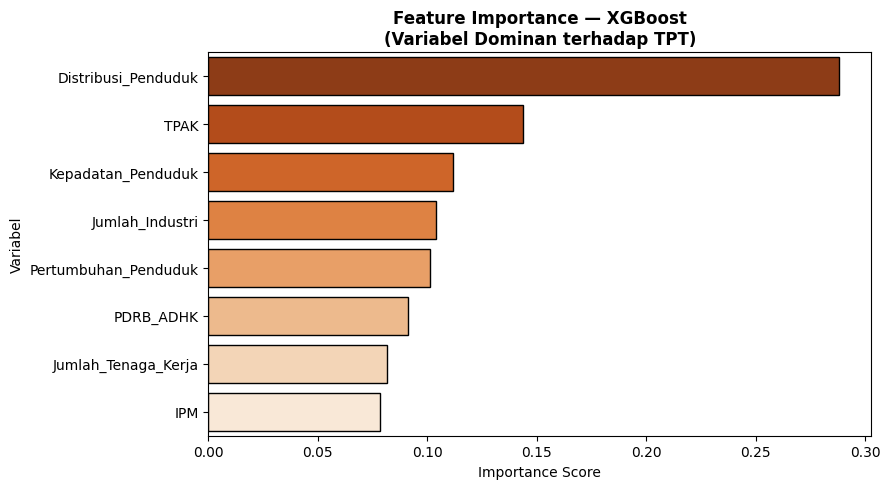

Grafik disimpan: feature_importance_xgb.png


In [11]:
# Hitung feature importance dari semua fitur (termasuk Kota_encoded & Tahun)
fi_xgb = pd.DataFrame({
    'Variabel'   : X_train.columns,
    'Importance' : xgb_best.feature_importances_
})
fi_xgb = fi_xgb.sort_values('Importance', ascending=False)

# Filter hanya 8 variabel sosial ekonomi untuk visualisasi
fi_xgb_viz = fi_xgb[fi_xgb['Variabel'].isin(FITUR_SOSEK)].copy()
# Normalisasi ulang agar total importance = 1.0
fi_xgb_viz['Importance'] = fi_xgb_viz['Importance'] / fi_xgb_viz['Importance'].sum()
fi_xgb_viz = fi_xgb_viz.sort_values('Importance', ascending=False).reset_index(drop=True)

print("=" * 50)
print("   FEATURE IMPORTANCE — XGBoost (Semua Kota)")
print("=" * 50)
display(fi_xgb_viz)

plt.figure(figsize=(9, 5))
sns.barplot(data=fi_xgb_viz, x='Importance', y='Variabel', palette='Oranges_r', edgecolor='black')
plt.title('Feature Importance — XGBoost\n(Variabel Dominan terhadap TPT)', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: feature_importance_xgb.png")

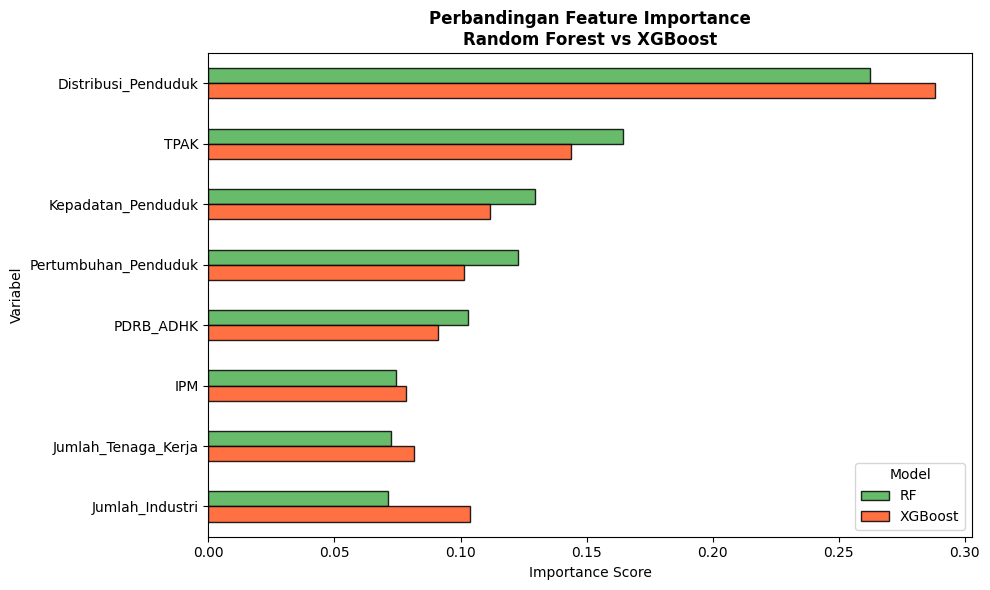

Grafik disimpan: feature_importance_comparison.png


In [12]:
# Gabungkan hasil feature importance RF dan XGBoost (sudah difilter 8 variabel)
fi_compare = fi_rf_viz.rename(columns={'Importance': 'RF'}).merge(
    fi_xgb_viz.rename(columns={'Importance': 'XGBoost'}), on='Variabel'
).set_index('Variabel')

fi_compare.plot(kind='barh', figsize=(10, 6),
                color=['#4CAF50', '#FF5722'], edgecolor='black', alpha=0.85)
plt.title('Perbandingan Feature Importance\nRandom Forest vs XGBoost', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.legend(title='Model')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: feature_importance_comparison.png")

In [13]:
# ============================================================
# [REVISI] Feature Importance Khusus 3 Kota Berpenduduk Terbanyak
# ============================================================

# Identifikasi top-3 kota berdasarkan rata-rata Jumlah_Penduduk (ribu jiwa)
FITUR_KOTA = [
    'PDRB_ADHK', 'IPM', 'TPAK',
    'Jumlah_Industri', 'Jumlah_Tenaga_Kerja',
    'Distribusi_Penduduk', 'Pertumbuhan_Penduduk', 'Kepadatan_Penduduk'
]

top3 = (data.groupby('Kabupaten/Kota')['Jumlah_Penduduk']
            .mean()
            .sort_values(ascending=False)
            .head(3)
            .index.tolist())

print("Top 3 kota berpenduduk terbanyak:", top3)
print("(Analisis feature importance dilakukan per kota menggunakan 8 fitur sosial-ekonomi tanpa encode)")

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

results_fi_top3 = {}

for kota in top3:
    sub = data[data['Kabupaten/Kota'] == kota][FITUR_KOTA + ['TPT']].copy()
    X_k = sub[FITUR_KOTA]
    y_k = sub['TPT']

    rf_k = RandomForestRegressor(n_estimators=300, random_state=42)
    rf_k.fit(X_k, y_k)

    xgb_k = XGBRegressor(n_estimators=300, random_state=42, verbosity=0)
    xgb_k.fit(X_k, y_k)

    fi_df = pd.DataFrame({
        'Variabel'     : FITUR_KOTA,
        'Random Forest': rf_k.feature_importances_,
        'XGBoost'      : xgb_k.feature_importances_
    })
    fi_df['Rata-rata'] = (fi_df['Random Forest'] + fi_df['XGBoost']) / 2
    fi_df = fi_df.sort_values('Rata-rata', ascending=False).reset_index(drop=True)
    results_fi_top3[kota] = fi_df

    print(f"\n=== Feature Importance — {kota} ===")
    display(fi_df)

Top 3 kota berpenduduk terbanyak: ['Brebes', 'Cilacap', 'Banyumas']
(Analisis feature importance dilakukan per kota menggunakan 8 fitur sosial-ekonomi tanpa encode)

=== Feature Importance — Brebes ===


,Variabel,Random Forest,XGBoost,Rata-rata
0,IPM,0.217687,0.986391,0.602039
1,Jumlah_Industri,0.255902,0.000000,0.127951
2,Pertumbuhan_Penduduk,0.143578,0.000003,0.071791
3,PDRB_ADHK,0.122252,0.013595,0.067924
4,Distribusi_Penduduk,0.090083,0.000008,0.045045
5,TPAK,0.061183,0.000003,0.030593
6,Jumlah_Tenaga_Kerja,0.059170,0.000000,0.029585
7,Kepadatan_Penduduk,0.050144,0.000000,0.025072



=== Feature Importance — Cilacap ===


,Variabel,Random Forest,XGBoost,Rata-rata
0,Pertumbuhan_Penduduk,0.173523,0.940558,0.557040
1,Kepadatan_Penduduk,0.221283,0.000000,0.110641
2,TPAK,0.164146,0.042208,0.103177
3,PDRB_ADHK,0.110748,0.017155,0.063952
4,Jumlah_Tenaga_Kerja,0.122167,0.000000,0.061084
5,Distribusi_Penduduk,0.105545,0.000054,0.052800
6,IPM,0.069087,0.000003,0.034545
7,Jumlah_Industri,0.033500,0.000021,0.016760



=== Feature Importance — Banyumas ===


,Variabel,Random Forest,XGBoost,Rata-rata
0,TPAK,0.364790,0.997584,0.681187
1,Kepadatan_Penduduk,0.287713,0.000000,0.143857
2,PDRB_ADHK,0.094207,0.002417,0.048312
3,Jumlah_Tenaga_Kerja,0.073870,0.000000,0.036935
4,IPM,0.064230,0.000000,0.032115
5,Jumlah_Industri,0.056573,0.000000,0.028286
6,Pertumbuhan_Penduduk,0.040080,0.000000,0.020040
7,Distribusi_Penduduk,0.018537,0.000000,0.009268


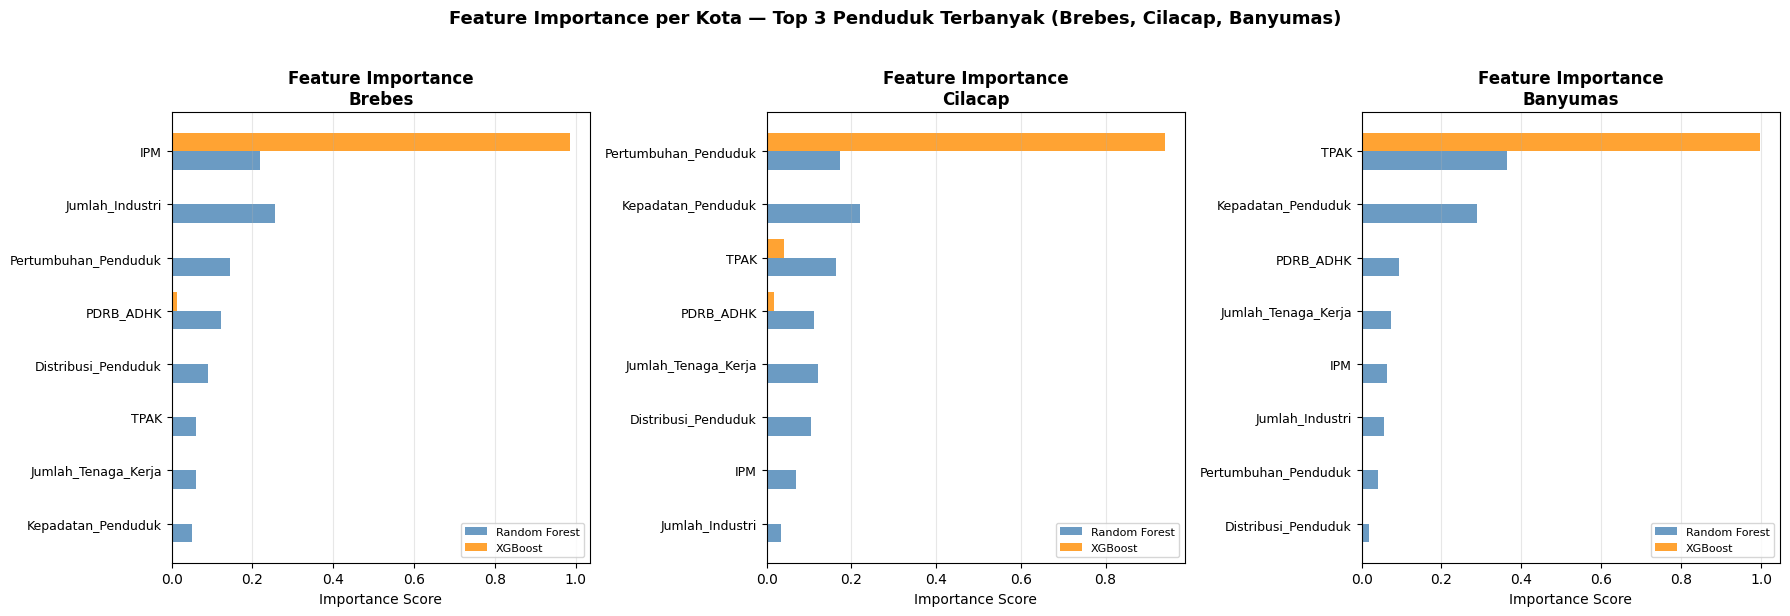

Grafik disimpan: feature_importance_top3_kota.png


In [14]:
# Visualisasi Feature Importance 3 kota berpenduduk terbanyak
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, kota in zip(axes, top3):
    fi = results_fi_top3[kota].sort_values('Rata-rata')
    x  = range(len(fi))
    width = 0.35
    ax.barh([i - width/2 for i in x], fi['Random Forest'],
            height=width, label='Random Forest', color='steelblue', alpha=0.8)
    ax.barh([i + width/2 for i in x], fi['XGBoost'],
            height=width, label='XGBoost', color='darkorange', alpha=0.8)
    ax.set_yticks(list(x))
    ax.set_yticklabels(fi['Variabel'].tolist(), fontsize=9)
    ax.set_title(f'Feature Importance\n{kota}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance per Kota — Top 3 Penduduk Terbanyak (Brebes, Cilacap, Banyumas)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance_top3_kota.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: feature_importance_top3_kota.png")

In [15]:
# ============================================================
# [REVISI] Prediksi TPT per Kabupaten/Kota (seluruh data)
# ============================================================

# Reset index agar urutan data konsisten
data = data.reset_index(drop=True)

X_all = data[FITUR]
data['TPT_pred_LR']  = lr_model.predict(X_all)
data['TPT_pred_RF']  = rf_best.predict(X_all)
data['TPT_pred_XGB'] = xgb_best.predict(X_all)

# Buat salinan untuk keperluan interpolasi provinsi
data_pred = data.copy()

# Tampilkan prediksi semua kota semua tahun
pred_all = (data[['Kabupaten/Kota', 'Tahun', 'TPT', 'TPT_pred_LR', 'TPT_pred_RF', 'TPT_pred_XGB']]
            .copy().reset_index(drop=True))
pred_all.columns = ['Kota', 'Tahun', 'TPT Aktual', 'Pred LR', 'Pred RF', 'Pred XGB']

print("=== Prediksi TPT per Kota — Semua Tahun (210 data) ===")
display(pred_all.round(4))

# Cek Tegal 2023 sebagai verifikasi
print("\nVerifikasi Tegal 2023:")
display(pred_all[(pred_all['Kota'] == 'Tegal') & (pred_all['Tahun'] == 2023)].round(4))

=== Prediksi TPT per Kota — Semua Tahun (210 data) ===


,Kota,Tahun,TPT Aktual,Pred LR,Pred RF,Pred XGB
0,Cilacap,2018,7.49,7.3928,7.1417,7.4951
1,Cilacap,2019,7.24,7.6199,7.1265,7.2208
2,Cilacap,2020,9.10,8.7339,8.7157,9.0459
3,Cilacap,2021,9.97,8.7899,9.6802,9.9116
4,Cilacap,2022,9.62,8.6736,9.4464,9.6430
...,...,...,...,...,...,...
205,Kota Tegal,2019,8.08,5.6850,7.0650,8.0770
206,Kota Tegal,2020,8.40,7.2310,7.7757,8.3726
207,Kota Tegal,2021,8.25,7.0364,7.3431,7.7935
208,Kota Tegal,2022,6.68,7.5108,6.5835,6.6417



Verifikasi Tegal 2023:


,Kota,Tahun,TPT Aktual,Pred LR,Pred RF,Pred XGB
167,Tegal,2023,8.6,6.4018,7.4086,8.4758


In [16]:
# Cell kosong (debugging df_ak sudah dihapus)

In [17]:
# ============================================================
# [REVISI] Interpolasi TPT Provinsi Jawa Tengah
# menggunakan weighted average berbobot Angkatan Kerja BPS
#
# Formula: TPT_Provinsi = Σ(TPT_i × AK_i) / Σ(AK_i)
# ============================================================

def interpolasi_provinsi(df_sub, tpt_col):
    num = (df_sub[tpt_col] * df_sub['Angkatan_Kerja']).sum()
    den = df_sub['Angkatan_Kerja'].sum()
    return num / den

rows = []
for tahun in sorted(data['Tahun'].unique()):
    sub = data[data['Tahun'] == tahun].copy()
    rows.append({
        'Tahun'                 : tahun,
        'TPT_Aktual_Provinsi'   : interpolasi_provinsi(sub, 'TPT'),
        'TPT_Pred_LR_Provinsi'  : interpolasi_provinsi(sub, 'TPT_pred_LR'),
        'TPT_Pred_RF_Provinsi'  : interpolasi_provinsi(sub, 'TPT_pred_RF'),
        'TPT_Pred_XGB_Provinsi' : interpolasi_provinsi(sub, 'TPT_pred_XGB'),
    })

df_prov = pd.DataFrame(rows)

print("=== TPT Provinsi Jawa Tengah: Aktual vs Prediksi (Interpolasi Berbobot AK) ===")
display(df_prov.round(4))

# Error interpolasi provinsi
print("\n=== Error Interpolasi Provinsi ===")
for col, label in [('TPT_Pred_LR_Provinsi','Regresi Linear'),
                   ('TPT_Pred_RF_Provinsi','Random Forest'),
                   ('TPT_Pred_XGB_Provinsi','XGBoost')]:
    mae_p  = np.mean(np.abs(df_prov['TPT_Aktual_Provinsi'] - df_prov[col]))
    mape_p = np.mean(np.abs((df_prov['TPT_Aktual_Provinsi'] - df_prov[col]) /
                             df_prov['TPT_Aktual_Provinsi'])) * 100
    print(f"{label:20s} — MAE={mae_p:.4f}  MAPE={mape_p:.2f}%")

=== TPT Provinsi Jawa Tengah: Aktual vs Prediksi (Interpolasi Berbobot AK) ===


,Tahun,TPT_Aktual_Provinsi,TPT_Pred_LR_Provinsi,TPT_Pred_RF_Provinsi,TPT_Pred_XGB_Provinsi
0,2018,4.4707,4.7193,4.7533,4.5461
1,2019,4.4410,5.1320,4.7440,4.5303
2,2020,6.4762,6.1972,6.2977,6.4869
3,2021,5.9499,5.3095,5.6886,5.8773
4,2022,5.5683,5.3048,5.4579,5.5204
5,2023,5.1268,5.3737,5.0868,5.1383



=== Error Interpolasi Provinsi ===
Regresi Linear       — MAE=0.3949  MAPE=7.62%
Random Forest        — MAE=0.1960  MAPE=3.84%
XGBoost              — MAE=0.0512  MAPE=1.03%


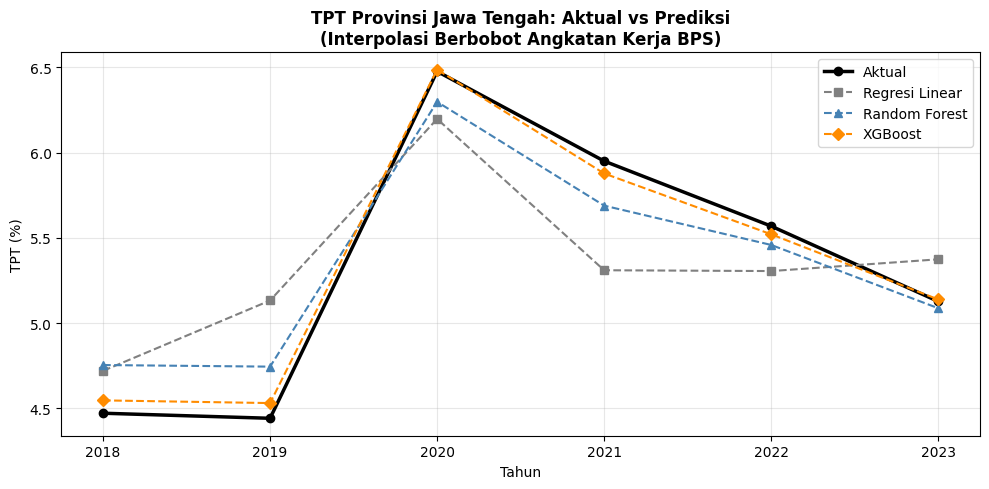

Grafik disimpan: tpt_provinsi_interpolasi.png


In [18]:
# Visualisasi TPT Provinsi: Aktual vs Prediksi
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_prov['Tahun'], df_prov['TPT_Aktual_Provinsi'],
        marker='o', linewidth=2.5, label='Aktual', color='black')
ax.plot(df_prov['Tahun'], df_prov['TPT_Pred_LR_Provinsi'],
        marker='s', linestyle='--', label='Regresi Linear', color='gray')
ax.plot(df_prov['Tahun'], df_prov['TPT_Pred_RF_Provinsi'],
        marker='^', linestyle='--', label='Random Forest', color='steelblue')
ax.plot(df_prov['Tahun'], df_prov['TPT_Pred_XGB_Provinsi'],
        marker='D', linestyle='--', label='XGBoost', color='darkorange')

ax.set_title('TPT Provinsi Jawa Tengah: Aktual vs Prediksi\n(Interpolasi Berbobot Angkatan Kerja BPS)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Tahun')
ax.set_ylabel('TPT (%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('tpt_provinsi_interpolasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: tpt_provinsi_interpolasi.png")

In [19]:
# Menampilkan ringkasan hasil evaluasi seluruh model
print("=" * 65)
print("         RINGKASAN HASIL PEMODELAN")
print("=" * 65)

display(results_df.set_index('Model'))

print("=" * 65)

print("\nBest Hyperparameters — Random Forest:")
for k, v in rf_random.best_params_.items():
    print(f"   {k:25s}: {v}")

print("\nBest Hyperparameters — XGBoost:")
for k, v in xgb_random.best_params_.items():
    print(f"   {k:25s}: {v}")

print("\nVariabel Paling Dominan (Random Forest — Semua Kota):")
print(f"   → {fi_rf_viz.iloc[0]['Variabel']} (importance = {fi_rf_viz.iloc[0]['Importance']:.4f})")

print("\nVariabel Paling Dominan (XGBoost — Semua Kota):")
print(f"   → {fi_xgb_viz.iloc[0]['Variabel']} (importance = {fi_xgb_viz.iloc[0]['Importance']:.4f})")

print("\n[REVISI] Variabel Paling Dominan per Kota (Top-3 Penduduk):")
for kota in top3:
    top_var = results_fi_top3[kota].iloc[0]
    print(f"   {kota:15s}: {top_var['Variabel']} (rata-rata = {top_var['Rata-rata']:.4f})")

print("=" * 65)

         RINGKASAN HASIL PEMODELAN


,R²,RMSE,MAE,MAPE (%)
Model,,,,
Regresi Linear (Baseline),0.3977,1.6321,1.3550,31.6304
Random Forest (Tuned),0.7196,1.1136,0.9161,21.6018
XGBoost (Tuned),0.8515,0.8105,0.6566,15.7116



Best Hyperparameters — Random Forest:
   n_estimators             : 100
   min_samples_split        : 2
   min_samples_leaf         : 1
   max_features             : 0.5
   max_depth                : None

Best Hyperparameters — XGBoost:
   subsample                : 0.8
   n_estimators             : 100
   min_child_weight         : 3
   max_depth                : 7
   learning_rate            : 0.1
   gamma                    : 0
   colsample_bytree         : 0.6

Variabel Paling Dominan (Random Forest — Semua Kota):
   → Distribusi_Penduduk (importance = 0.2624)

Variabel Paling Dominan (XGBoost — Semua Kota):
   → Distribusi_Penduduk (importance = 0.2883)

[REVISI] Variabel Paling Dominan per Kota (Top-3 Penduduk):
   Brebes         : IPM (rata-rata = 0.6020)
   Cilacap        : Pertumbuhan_Penduduk (rata-rata = 0.5570)
   Banyumas       : TPAK (rata-rata = 0.6812)
